# Análisis Inteligente del Consumo Energético

El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de clasificar el nivel de eficiencia energética de una vivienda o pequeño establecimiento a partir de diferentes características relacionadas con el consumo eléctrico.

Se generará un dataset sintético que represente distintos perfiles de consumo.

Posteriormente se realizará un análisis exploratorio de los datos (EDA), el entrenamiento de modelos supervisados y la evaluación de su desempeño para seleccionar el modelo más adecuado.

# Variables del Dataset

Para representar el comportamiento energético de una vivienda se seleccionaron las siguientes variables.

1. Fecha

      Tipo: Fecha (YYYY-MM)

      - Representa el período al que corresponde el consumo energético registrado.

      Permite realizar análisis temporales como:

      - Evolución del consumo.

      - Comparación entre meses.

      - Tendencias de eficiencia.

      - Variaciones estacionales.

2. Consumo mensual (kWh)

      Tipo: Numérica

      Representa la cantidad de energía consumida durante un mes.

      Es la variable principal del problema y será utilizada para:

      - Estimar el costo mensual.

      - Analizar patrones de consumo.

      - Detectar consumos elevados.
      
3. Uso en horario pico

      Tipo: Booleana

      Indica si la mayor parte del consumo ocurre durante los horarios de mayor demanda eléctrica.

      Su análisis permite:

      - Detectar hábitos poco eficientes.

      - Generar recomendaciones para redistribuir el consumo.

4. Horas de alto consumo

      Tipo: Numérica

      Cantidad aproximada de horas diarias durante las cuales el consumo eléctrico es elevado.

      Permite identificar:

      - Intensidad del uso energético.

      - Relación entre tiempo de uso y consumo mensual.

5. Cantidad de equipos eléctricos

      Tipo: Numérica

      Número de electrodomésticos o equipos eléctricos utilizados regularmente.

      - Esta variable permite analizar cómo influye la cantidad de dispositivos sobre el consumo energético.

6. Cantidad de personas

      Tipo: Numérica

      - Cantidad de personas que habitan el inmueble.

      Se incorpora debido a que el consumo suele aumentar con el número de habitantes.

7. Tipo de inmueble

      Tipo: Categórica

      Puede tomar los valores:

      - Casa

      - Departamento

      - Comercio

      Permite analizar diferencias de consumo entre distintos tipos de establecimientos.

8. Categoría de eficiencia energética (Target)

      Tipo: Categórica

      Representa la clasificación que el modelo deberá aprender.

      Se utilizarán tres categorías:

      - Eficiente

      - Moderado
      
      - Ineficiente

      Las etiquetas serán generadas mediante un conjunto de reglas que consideran el consumo energético y otros factores relacionados con los hábitos de uso.

# Generación del Dataset

Se desarrolló un generador de datos sintéticos.

El objetivo es representar distintos perfiles de consumo energético manteniendo relaciones coherentes entre las variables.

Se generarán 10000 registros correspondientes a distintos inmuebles con características variadas.

Posteriormente estas observaciones serán utilizadas para entrenar y evaluar modelos supervisados de clasificación.

In [1]:
import random
import pandas as pd
from datetime import datetime

NUM_REGISTROS = 10000

TIPOS_INMUEBLE = [
    "Casa",
    "Departamento",
    "Comercio"
]
def generar_fecha():

    año = random.randint(2023, 2025)
    mes = random.randint(1, 12)

    fecha = f"{año}-{mes:02d}"

    return fecha, mes


def generar_tipo():
    return random.choices(
        TIPOS_INMUEBLE,
        weights=[50, 35, 15]
    )[0]


def generar_personas(tipo):

    if tipo == "Casa":
        return random.randint(2, 6)

    elif tipo == "Departamento":
        return random.randint(1, 4)

    return random.randint(2, 8)


def generar_equipos(personas):
    return random.randint(personas + 2, personas + 10)


def generar_horas():
    return random.randint(2, 12)


def generar_horario_pico():
    return random.random() < 0.65

def calcular_consumo(personas, equipos, horas, horario_pico, mes):

    consumo = 80

    # Consumo base
    consumo += personas * random.randint(20, 35)
    consumo += equipos * random.randint(6, 10)
    consumo += horas * random.randint(8, 15)

    # Horario pico
    if horario_pico:
        consumo += random.randint(20, 50)

    # Estacionalidad
    if mes in [12, 1, 2]:          # Verano
        consumo += random.randint(40, 80)

    elif mes in [6, 7, 8]:         # Invierno
        consumo += random.randint(30, 70)

    # -------- PERFIL DEL USUARIO --------
    perfil = random.choices(
        ["Eficiente", "Moderado", "Ineficiente"],
        weights=[30, 45, 25]
    )[0]

    if perfil == "Eficiente":
        consumo *= random.uniform(0.80, 0.98)

    elif perfil == "Moderado":
        consumo *= random.uniform(0.98, 1.15)

    else:
        consumo *= random.uniform(1.20, 1.60)

    # Variación natural
    consumo += random.randint(-15, 15)

    return round(max(consumo, 100), 2)


def calcular_consumo_esperado(personas,
                               equipos,
                               horas,
                               horario_pico,
                               mes):

    esperado = 80

    esperado += personas * 28
    esperado += equipos * 8
    esperado += horas * 11

    if horario_pico:
        esperado += 30

    if mes in [12, 1, 2]:
        esperado += 60

    elif mes in [6, 7, 8]:
        esperado += 50

    return esperado

def calcular_indice(consumo_real, consumo_esperado):

    relacion = consumo_real / consumo_esperado

    if relacion <= 1:
        indice = random.randint(85,100)

    elif relacion <= 1.15:
        indice = random.randint(70,84)

    elif relacion <= 1.30:
        indice = random.randint(50,69)

    else:
        indice = random.randint(20,49)

    return indice


def clasificar(consumo_real, consumo_esperado):

    relacion = consumo_real / consumo_esperado

    if relacion <= 1.05:
        return "Eficiente"

    elif relacion <= 1.25:
        return "Moderado"

    else:
        return "Ineficiente"


def generar_registro():

    fecha, mes = generar_fecha()

    tipo = generar_tipo()

    personas = generar_personas(tipo)

    equipos = generar_equipos(personas)

    horas = generar_horas()

    horario_pico = generar_horario_pico()

    consumo = calcular_consumo(
        personas,
        equipos,
        horas,
        horario_pico,
        mes
    )

    consumo_esperado = calcular_consumo_esperado(
        personas,
        equipos,
        horas,
        horario_pico,
        mes
    )

    categoria = clasificar(
        consumo,
        consumo_esperado
    )

    return {
        "fecha": fecha,
        "mes": mes,
        "consumo_kwh": consumo,
        "consumo_esperado": consumo_esperado,
        "uso_horario_pico": horario_pico,
        "horas_alto_consumo": horas,
        "cantidad_equipos": equipos,
        "cantidad_personas": personas,
        "tipo_inmueble": tipo,
        "categoria": categoria
    }
dataset = []

for _ in range(NUM_REGISTROS):
    dataset.append(generar_registro())

df = pd.DataFrame(dataset)

df.to_csv(
    "consumo_energetico.csv",
    index=False,
    encoding="utf-8"
)

print(df.head())

print("\nDistribución de categorías:")
print(df["categoria"].value_counts())

     fecha  mes  consumo_kwh  consumo_esperado  uso_horario_pico  \
0  2024-03    3       343.17               369              True   
1  2023-12   12       370.14               327             False   
2  2023-12   12       580.25               527              True   
3  2024-11   11       309.80               247              True   
4  2025-09    9       468.60               374              True   

   horas_alto_consumo  cantidad_equipos  cantidad_personas tipo_inmueble  \
0                   9                 6                  4  Departamento   
1                   9                 4                  2          Casa   
2                   7                14                  6          Casa   
3                   3                 6                  2  Departamento   
4                   8                 8                  4          Casa   

     categoria  
0    Eficiente  
1     Moderado  
2     Moderado  
3  Ineficiente  
4  Ineficiente  

Distribución de categorías:
cat

#Conociendo el Dataset

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("consumo_energetico.csv")

In [3]:
print("Primeros registros")
df.head()

Primeros registros


,fecha,mes,consumo_kwh,consumo_esperado,uso_horario_pico,horas_alto_consumo,cantidad_equipos,cantidad_personas,tipo_inmueble,categoria
0,2024-03,3,343.17,369,True,9,6,4,Departamento,Eficiente
1,2023-12,12,370.14,327,False,9,4,2,Casa,Moderado
2,2023-12,12,580.25,527,True,7,14,6,Casa,Moderado
3,2024-11,11,309.80,247,True,3,6,2,Departamento,Ineficiente
4,2025-09,9,468.60,374,True,8,8,4,Casa,Ineficiente


In [4]:
print("Últimos registros")
df.tail()

Últimos registros


,fecha,mes,consumo_kwh,consumo_esperado,uso_horario_pico,horas_alto_consumo,cantidad_equipos,cantidad_personas,tipo_inmueble,categoria
9995,2023-12,12,226.15,317,True,5,8,1,Departamento,Eficiente
9996,2024-04,4,404.44,364,False,12,12,2,Comercio,Moderado
9997,2024-12,12,482.31,496,True,6,15,5,Comercio,Eficiente
9998,2024-04,4,330.39,311,True,3,7,4,Casa,Moderado
9999,2023-01,1,562.19,471,True,11,12,3,Departamento,Moderado


In [5]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 10000
Columnas: 10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               10000 non-null  object 
 1   mes                 10000 non-null  int64  
 2   consumo_kwh         10000 non-null  float64
 3   consumo_esperado    10000 non-null  int64  
 4   uso_horario_pico    10000 non-null  bool   
 5   horas_alto_consumo  10000 non-null  int64  
 6   cantidad_equipos    10000 non-null  int64  
 7   cantidad_personas   10000 non-null  int64  
 8   tipo_inmueble       10000 non-null  object 
 9   categoria           10000 non-null  object 
dtypes: bool(1), float64(1), int64(5), object(3)
memory usage: 713.0+ KB


In [7]:
df.describe()

,mes,consumo_kwh,consumo_esperado,horas_alto_consumo,cantidad_equipos,cantidad_personas
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.497500,423.723346,381.801500,6.955900,9.621400,3.611800
std,3.475572,124.607126,79.132023,3.147435,3.060523,1.681423
min,1.000000,131.250000,154.000000,2.000000,3.000000,1.000000
25%,3.000000,334.887500,326.000000,4.000000,7.000000,2.000000
50%,6.000000,407.010000,379.000000,7.000000,10.000000,3.000000
75%,10.000000,495.612500,434.000000,10.000000,12.000000,5.000000
max,12.000000,1057.040000,660.000000,12.000000,18.000000,8.000000


In [8]:
print("Consumo promedio")

print(df["consumo_kwh"].mean())



Consumo promedio
423.723346


In [9]:
print("Consumo mínimo")
print(df["consumo_kwh"].min())

print("Consumo máximo")
print(df["consumo_kwh"].max())

Consumo mínimo
131.25
Consumo máximo
1057.04


In [10]:
df["categoria"].value_counts()

,count
categoria,
Eficiente,4649
Moderado,3058
Ineficiente,2293


In [11]:
round(
    df["categoria"].value_counts(normalize=True)*100,
    2
)

,proportion
categoria,
Eficiente,46.49
Moderado,30.58
Ineficiente,22.93


In [12]:
df["tipo_inmueble"].value_counts()

,count
tipo_inmueble,
Casa,4947
Departamento,3554
Comercio,1499


In [13]:
round(
    df["tipo_inmueble"].value_counts(normalize=True)*100,
    2
)

,proportion
tipo_inmueble,
Casa,49.47
Departamento,35.54
Comercio,14.99


In [14]:
df["uso_horario_pico"].value_counts()

,count
uso_horario_pico,
True,6520
False,3480


In [15]:
round(
    df["uso_horario_pico"].value_counts(normalize=True)*100,
    2
)

,proportion
uso_horario_pico,
True,65.2
False,34.8


In [16]:
df.groupby("tipo_inmueble")["consumo_kwh"].mean().sort_values(ascending=False)

,consumo_kwh
tipo_inmueble,
Comercio,483.965904
Casa,436.896657
Departamento,379.977718


In [17]:
df.groupby("categoria")["consumo_kwh"].mean()

,consumo_kwh
categoria,
Eficiente,354.114870
Ineficiente,553.890336
Moderado,431.943391


#Modelo Inicial

### Selección del modelo

Para este proyecto se seleccionó **Random Forest** como algoritmo de clasificación debido a sus características y ventajas para este tipo de problema.

Las principales razones son:

- Trabaja muy bien con variables numéricas y categóricas.
- Es capaz de aprender relaciones no lineales entre las variables.
- Es menos propenso al sobreajuste que un único Árbol de Decisión, ya que combina las predicciones de múltiples árboles.
- Requiere poco preprocesamiento de los datos, ya que no necesita normalización o estandarización.
- Permite obtener la importancia de cada variable, facilitando la interpretación del modelo y el análisis de qué factores influyen más en la eficiencia energética.



In [18]:
df["fecha"] = pd.to_datetime(df["fecha"])

df["mes"] = df["fecha"].dt.month

In [19]:
df = df.drop(columns=["fecha"])

df = df.drop(columns=["consumo_esperado"])

Se define **X** como el conjunto de variables predictoras (features), es decir, todas aquellas características que describen el perfil de consumo energético y que serán utilizadas por el modelo para realizar la clasificación.

La variable **y** representa la variable objetivo (*target*), correspondiente a la categoría de eficiencia energética que el modelo deberá aprender a predecir.

In [20]:
X = df.drop(columns=["categoria"])

y = df["categoria"]

In [21]:
print(X.head())
print(y.head())

   mes  consumo_kwh  uso_horario_pico  horas_alto_consumo  cantidad_equipos  \
0    3       343.17              True                   9                 6   
1   12       370.14             False                   9                 4   
2   12       580.25              True                   7                14   
3   11       309.80              True                   3                 6   
4    9       468.60              True                   8                 8   

   cantidad_personas tipo_inmueble  
0                  4  Departamento  
1                  2          Casa  
2                  6          Casa  
3                  2  Departamento  
4                  4          Casa  
0      Eficiente
1       Moderado
2       Moderado
3    Ineficiente
4    Ineficiente
Name: categoria, dtype: object


Se utiliza la función `train_test_split` para dividir el conjunto de datos en un subconjunto de entrenamiento y otro de prueba.

El conjunto de datos se divide en:

- **80 %** para entrenamiento del modelo.
- **20 %** para evaluación del desempeño.

Además:

- **random_state = 42** garantiza que la división sea reproducible en futuras ejecuciones.
- **stratify = y** mantiene la misma proporción de cada categoría (Eficiente, Moderado e Ineficiente) tanto en el conjunto de entrenamiento como en el de prueba, evitando sesgos durante la evaluación.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

El modelo de Machine Learning requiere que todas las variables de entrada sean numéricas. Sin embargo, la variable **tipo_inmueble** contiene valores categóricos ("Casa", "Departamento" y "Comercio"), por lo que debe transformarse antes del entrenamiento.

Se utiliza un **ColumnTransformer** para aplicar transformaciones únicamente a las columnas que lo requieren.

En este caso:

- La columna **tipo_inmueble** se transforma mediante **One-Hot Encoding**, generando una columna binaria para cada categoría.
- El resto de las variables numéricas se mantienen sin modificaciones mediante la opción `remainder="passthrough"`.

El parámetro `handle_unknown="ignore"` permite que el modelo continúe funcionando incluso si durante la predicción aparece una categoría no observada durante el entrenamiento.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "tipo",
            OneHotEncoder(handle_unknown="ignore"),
            ["tipo_inmueble"]
        )
    ],
    remainder="passthrough"
)

Se utiliza un **Pipeline** para integrar el preprocesamiento y el modelo de clasificación en un único flujo de trabajo.

Esto garantiza que cualquier dato nuevo pase automáticamente por las mismas transformaciones antes de ser clasificado, evitando inconsistencias entre el entrenamiento y la predicción.

El Pipeline está compuesto por dos etapas:

1. **Preprocesamiento:** transformación de las variables categóricas mediante One-Hot Encoding.
2. **Clasificación:** entrenamiento del modelo Random Forest.

Se configuró el algoritmo con **200 árboles de decisión** (`n_estimators=200`), buscando mejorar la estabilidad de las predicciones mediante el voto conjunto de múltiples árboles.

El parámetro `random_state=42` garantiza que el entrenamiento sea reproducible, obteniendo los mismos resultados en ejecuciones posteriores.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

modelo = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

Finalmente, se entrena el modelo utilizando el conjunto de entrenamiento.

Durante esta etapa, Random Forest construye múltiples árboles de decisión a partir de diferentes subconjuntos de datos y variables. Cada árbol realiza una predicción de forma independiente y la clasificación final se obtiene mediante votación mayoritaria, lo que mejora la robustez y reduce el riesgo de sobreajuste.

In [25]:
modelo.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tipo',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['tipo_inmueble'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

Una vez entrenado el modelo, se realizan predicciones utilizando el conjunto de prueba (X_test), compuesto por datos que el algoritmo nunca vio durante el entrenamiento.

Esta etapa permite evaluar la capacidad del modelo para generalizar y clasificar correctamente nuevos perfiles de consumo energético.

In [26]:
predicciones = modelo.predict(X_test)

Además de indicar la categoría predicha, Random Forest puede estimar la probabilidad asociada a cada clase.

Esto permite conocer el nivel de confianza de la predicción realizada.

Por ejemplo, una salida como:

  [0.92, 0.03, 0.05]

  indica que el modelo considera un 92 % de probabilidad de que el registro pertenezca a la primera categoría.

In [27]:
probabilidades = modelo.predict_proba(X_test)

La métrica Accuracy mide el porcentaje de predicciones correctas realizadas por el modelo.

Se calcula comparando las categorías predichas con las categorías reales del conjunto de prueba.

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predicciones
)

print(accuracy)

0.8395


El Classification Report proporciona una evaluación más completa del desempeño del modelo para cada una de las categorías de eficiencia energética.

Precision

- Indica qué tan confiables son las predicciones realizadas por el modelo.

Recall

- Mide la capacidad del modelo para identificar correctamente todos los registros pertenecientes a una determinada categoría.

F1-Score

- Es una medida que combina Precision y Recall en un único indicador.

Support

- Representa la cantidad de registros pertenecientes a cada categoría dentro del conjunto de prueba.

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predicciones
    )
)

              precision    recall  f1-score   support

   Eficiente       0.86      0.92      0.89       930
 Ineficiente       0.90      0.87      0.89       459
    Moderado       0.76      0.70      0.73       611

    accuracy                           0.84      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.84      0.84      2000



La diagonal principal representa las predicciones correctas.

Todo lo que está fuera de la diagonal son errores de clasificación.

Eficiente(R)

Ineficiente(R)

Moderado(R)


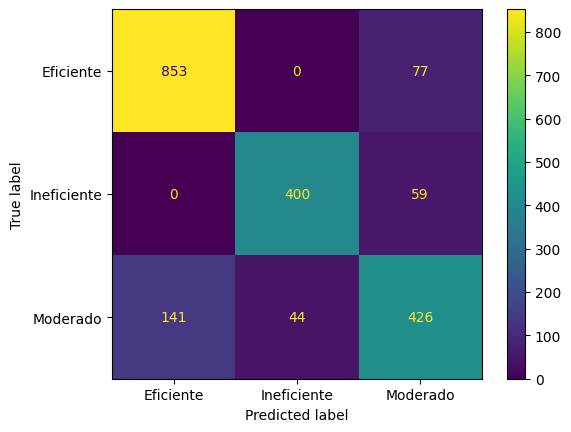

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)
plt.show()

Random Forest permite estimar la importancia relativa de cada variable utilizada durante el entrenamiento.

Esta información indica cuáles fueron los factores que más contribuyeron a la toma de decisiones del modelo.

In [31]:
import pandas as pd

importancias = modelo.named_steps["classifier"].feature_importances_

nombres = modelo.named_steps["preprocessor"].get_feature_names_out()

pd.DataFrame({
    "Variable": nombres,
    "Importancia": importancias
}).sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
4,remainder__consumo_kwh,0.499819
3,remainder__mes,0.118247
6,remainder__horas_alto_consumo,0.111573
7,remainder__cantidad_equipos,0.106309
8,remainder__cantidad_personas,0.103934
5,remainder__uso_horario_pico,0.030216
2,tipo__tipo_inmueble_Departamento,0.011637
0,tipo__tipo_inmueble_Casa,0.010523
1,tipo__tipo_inmueble_Comercio,0.007743


In [32]:
import joblib
import sklearn
import numpy
import scipy

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)

joblib.dump(
    modelo,
    "modelo_consumo.pkl"
)

scikit-learn: 1.6.1
joblib: 1.5.3
numpy: 2.0.2
scipy: 1.16.3


['modelo_consumo.pkl']

In [33]:
def generar_respuesta(datosClientes, categoria, probabilidad):

    recomendaciones = []
    consumo_equipo = datosClientes["consumo_kwh"] / datosClientes["cantidad_equipos"]

    consumo_persona = datosClientes["consumo_kwh"] / datosClientes["cantidad_personas"]


    if datosClientes["uso_horario_pico"]:
        recomendaciones.append(
            "Reducir el uso de equipos durante los horarios pico para disminuir el costo de la energía."
        )
    if consumo_equipo > 60:

        recomendaciones.append(
            "El consumo promedio por equipo es elevado. Revise si existen electrodomésticos antiguos o de baja eficiencia energética."
        )

    elif consumo_equipo < 30:

        recomendaciones.append(
            "El consumo por equipo es bajo, lo que indica un buen aprovechamiento de los dispositivos instalados."
        )

    if datosClientes["horas_alto_consumo"] >= 8:
        recomendaciones.append(
            "Distribuir las actividades de mayor consumo a lo largo del día para evitar largos períodos de alta demanda."
        )

    if (
        datosClientes["tipo_inmueble"] == "Casa"
        and datosClientes["consumo_kwh"] > 550
    ):
        recomendaciones.append(
            "Debido al nivel de consumo, podría evaluar la instalación de paneles solares para reducir el costo energético."
        )

    if datosClientes["mes"] in [12, 1, 2]:
        recomendaciones.append(
            "En verano, configure el aire acondicionado entre 24°C y 26°C para mejorar la eficiencia."
        )

    if datosClientes["mes"] in [6, 7, 8]:
        recomendaciones.append(
            "En invierno, mejore el aislamiento de puertas y ventanas para disminuir el uso de calefacción."
        )

    if len(recomendaciones) == 0:
        recomendaciones.append(
            "El consumo energético es adecuado. Mantenga los hábitos actuales."
        )

    response = {
        "categoria": categoria,
        "probabilidad": round(float(probabilidad), 2),
        "costo_estimado_mensual": round(datosClientes["consumo_kwh"] * 0.75, 2),
        "recomendaciones": recomendaciones
    }

    return response

Simulacion, JSON -> DataFrame -> Predccion -> Respuesta

In [34]:

datos = {
    "consumo_kwh": 450,
    "uso_horario_pico": True,
    "cantidad_equipos": 9,
    "cantidad_personas": 6,
    "horas_alto_consumo": 3,
    "tipo_inmueble": "Casa",
    "mes": 7
}


entrada = pd.DataFrame([datos])

categoria = modelo.predict(entrada)[0]

probs = modelo.predict_proba(entrada)[0]
indice = list(modelo.classes_).index(categoria)
probabilidad = probs[indice]

respuesta = generar_respuesta(datos, categoria, probabilidad)

print(respuesta)

{'categoria': 'Eficiente', 'probabilidad': 0.51, 'costo_estimado_mensual': 337.5, 'recomendaciones': ['Reducir el uso de equipos durante los horarios pico para disminuir el costo de la energía.', 'En invierno, mejore el aislamiento de puertas y ventanas para disminuir el uso de calefacción.']}


In [37]:
import sklearn
import pandas
import numpy
import joblib

print("Scikit-Learn:", sklearn.__version__)
print("Pandas:", pandas.__version__)
print("NumPy:", numpy.__version__)
print("Joblib:", joblib.__version__)

Scikit-Learn: 1.6.1
Pandas: 2.2.2
NumPy: 2.0.2
Joblib: 1.5.3


#Recomendaciones Prueba

Generación de recomendaciones personalizadas

Además de clasificar el perfil energético, el sistema busca ofrecer recomendaciones claras y útiles para el usuario. Para ello, se definió un banco de mensajes organizado por categorías, donde cada una representa una posible situación detectada durante el análisis, como el uso en horario pico, un consumo elevado por equipo o recomendaciones estacionales.

Cada categoría contiene varias versiones de un mismo consejo. Esto permite que, ante situaciones similares, el sistema pueda variar la redacción de las recomendaciones, generando respuestas más naturales y evitando mostrar siempre exactamente el mismo texto.

La selección del mensaje se realiza de manera determinística mediante una función hash. De esta forma, un mismo conjunto de datos siempre obtendrá la misma recomendación, garantizando consistencia en los resultados, mientras que distintos perfiles de consumo podrán recibir variantes diferentes del mismo consejo.

Este enfoque mejora la experiencia del usuario sin modificar la lógica de negocio, ya que las recomendaciones siguen basándose en los mismos indicadores de eficiencia energética definidos por el equipo.

In [39]:
import hashlib

MENSAJES = {

    "horario_pico": [
        "Reducir el uso de equipos durante los horarios pico puede disminuir significativamente el costo de la energía.",
        "Trasladar parte del consumo fuera del horario pico ayuda a mejorar la eficiencia energética.",
        "Evite utilizar varios equipos de alto consumo simultáneamente durante el horario pico."
    ],

    "consumo_equipo_alto": [
        "El consumo promedio por equipo es elevado. Revise electrodomésticos antiguos o de baja eficiencia energética.",
        "Cada equipo presenta un consumo superior al esperado. Considere reemplazar los de mayor antigüedad.",
        "Se detectó un consumo elevado por dispositivo. Una revisión de los equipos puede generar importantes ahorros."
    ],

    "consumo_equipo_bajo": [
        "El consumo promedio por equipo es bajo. Los dispositivos parecen utilizarse eficientemente.",
        "Se observa un buen aprovechamiento de los equipos instalados.",
        "El consumo por dispositivo es reducido, indicando un uso eficiente."
    ],

    "consumo_persona_alto": [
        "El consumo por persona es elevado. Revise los hábitos de uso dentro del inmueble.",
        "Cada ocupante presenta un consumo superior al promedio esperado.",
        "El consumo energético por persona puede optimizarse mediante pequeños cambios de hábito."
    ],

    "horas_alto_consumo": [
        "Distribuya las actividades de mayor consumo durante el día para reducir picos de demanda.",
        "Evite concentrar todas las actividades eléctricas en pocas horas.",
        "Una mejor distribución del consumo diario puede mejorar la eficiencia energética."
    ],

    "paneles": [
        "Por el nivel de consumo, podría evaluar la instalación de paneles solares.",
        "Una vivienda con este consumo puede beneficiarse de energía solar fotovoltaica.",
        "El consumo registrado justifica analizar alternativas de generación renovable."
    ],

    "verano": [
        "Configure el aire acondicionado entre 24°C y 26°C para reducir el consumo.",
        "Evite temperaturas demasiado bajas en el aire acondicionado durante el verano.",
        "Utilice ventilación natural cuando sea posible antes de recurrir al aire acondicionado."
    ],

    "invierno": [
        "Mejorar el aislamiento de puertas y ventanas ayuda a reducir el uso de calefacción.",
        "Revise posibles pérdidas de calor para disminuir el consumo energético.",
        "Un buen aislamiento térmico puede reducir considerablemente el consumo en invierno."
    ],

    "consumo_muy_alto": [
        "El consumo mensual es muy elevado. Se recomienda realizar una auditoría energética.",
        "Se detectó un consumo significativamente superior al habitual.",
        "Conviene identificar los equipos responsables del mayor consumo eléctrico."
    ],

    "todo_correcto": [
        "El consumo energético es adecuado. Mantenga los hábitos actuales.",
        "No se detectan oportunidades importantes de mejora.",
        "El perfil energético es saludable. Continúe con las buenas prácticas."
    ]
}

Una vez definido el banco de recomendaciones, es necesario elegir qué variante mostrar al usuario. Para ello se implementó la función elegir_mensaje, cuya finalidad es seleccionar una de las alternativas disponibles de forma determinística.

En lugar de utilizar una selección completamente aleatoria, se emplea el algoritmo MD5 para generar un valor hash a partir de una clave. Posteriormente, este valor se transforma en un índice válido utilizando el operador módulo (%), permitiendo seleccionar una posición dentro de la lista de mensajes.

In [40]:
def elegir_mensaje(clave, opciones):

    indice = (
        int(
            hashlib.md5(clave.encode()).hexdigest(),
            16
        )
        % len(opciones)
    )

    return opciones[indice]

Cálculo de indicadores

Antes de generar las recomendaciones, el sistema calcula una serie de indicadores derivados a partir de la información recibida. Estos indicadores permiten analizar el consumo energético desde distintas perspectivas, en lugar de considerar únicamente el consumo total mensual.

Los indicadores calculados son:

- Consumo por equipo: representa el consumo promedio de energía por cada dispositivo registrado. Este valor permite detectar si los equipos presentan un consumo excesivo o si están siendo utilizados de manera eficiente.
- Consumo por persona: calcula el consumo promedio de energía por habitante del inmueble. Este indicador facilita comparar perfiles de consumo entre viviendas con distinta cantidad de ocupantes.
- Consumo por hora de alto consumo: mide el consumo promedio durante las horas en las que se registra una mayor demanda energética. Es útil para identificar si el gasto se encuentra concentrado en períodos específicos del día.

In [41]:
def calcular_indicadores(datos):

    return {

        "consumo_equipo":
            datos["consumo_kwh"] /
            max(datos["cantidad_equipos"],1),

        "consumo_persona":
            datos["consumo_kwh"] /
            max(datos["cantidad_personas"],1),

        "consumo_hora":
            datos["consumo_kwh"] /
            max(datos["horas_alto_consumo"],1)
    }

Generación de recomendaciones

Una vez obtenidos los indicadores de consumo, el sistema genera recomendaciones mediante un conjunto de reglas de negocio. A diferencia de la clasificación del perfil energético, que es realizada por el modelo de Machine Learning, las recomendaciones se construyen a partir de condiciones previamente definidas por el equipo.

In [42]:
def generar_recomendaciones(datos, indicadores):

    recomendaciones = []

    if datos["uso_horario_pico"]:

        recomendaciones.append({
            "prioridad":"Alta",
            "impacto":"Alto",
            "mensaje": elegir_mensaje(
                "horario_pico",
                MENSAJES["horario_pico"]
            )
        })

    if indicadores["consumo_equipo"] > 60:

        recomendaciones.append({
            "prioridad":"Alta",
            "impacto":"Alto",
            "mensaje": elegir_mensaje(
                "equipo_alto",
                MENSAJES["consumo_equipo_alto"]
            )
        })

    elif indicadores["consumo_equipo"] < 30:

        recomendaciones.append({
            "prioridad":"Baja",
            "impacto":"Bajo",
            "mensaje": elegir_mensaje(
                "equipo_bajo",
                MENSAJES["consumo_equipo_bajo"]
            )
        })

    if indicadores["consumo_persona"] > 150:

        recomendaciones.append({
            "prioridad":"Media",
            "impacto":"Medio",
            "mensaje": elegir_mensaje(
                "persona_alta",
                MENSAJES["consumo_persona_alto"]
            )
        })

    if datos["horas_alto_consumo"] >= 8:

        recomendaciones.append({
            "prioridad":"Media",
            "impacto":"Medio",
            "mensaje": elegir_mensaje(
                "horas",
                MENSAJES["horas_alto_consumo"]
            )
        })

    if (
        datos["tipo_inmueble"]=="Casa"
        and datos["consumo_kwh"]>550
    ):

        recomendaciones.append({
            "prioridad":"Media",
            "impacto":"Alto",
            "mensaje": elegir_mensaje(
                "solar",
                MENSAJES["paneles"]
            )
        })

    if datos["mes"] in [12,1,2]:

        recomendaciones.append({
            "prioridad":"Baja",
            "impacto":"Bajo",
            "mensaje": elegir_mensaje(
                "verano",
                MENSAJES["verano"]
            )
        })

    if datos["mes"] in [6,7,8]:

        recomendaciones.append({
            "prioridad":"Baja",
            "impacto":"Bajo",
            "mensaje": elegir_mensaje(
                "invierno",
                MENSAJES["invierno"]
            )
        })

    if datos["consumo_kwh"]>650:

        recomendaciones.append({
            "prioridad":"Alta",
            "impacto":"Alto",
            "mensaje": elegir_mensaje(
                "alto",
                MENSAJES["consumo_muy_alto"]
            )
        })

    if len(recomendaciones)==0:

        recomendaciones.append({
            "prioridad":"Información",
            "impacto":"Sin cambios",
            "mensaje": elegir_mensaje(
                "ok",
                MENSAJES["todo_correcto"]
            )
        })

    return recomendaciones

Estimación del costo energético

Como complemento al análisis del perfil energético, el sistema realiza una estimación del costo mensual de la energía eléctrica. Para ello, se utiliza una tarifa de referencia de 0,75 unidades monetarias por kWh, tal como se sugiere en la consigna

In [43]:
def calcular_costo(consumo):

    TARIFA = 0.75

    return round(consumo*TARIFA,2)

Punto de integración de toda la solución. Su objetivo es reunir los resultados obtenidos por el modelo de Machine Learning y por las reglas de negocio en una única estructura de datos que posteriormente será enviada al cliente en formato JSON.

In [44]:
def generar_respuesta(datos, categoria, probabilidad):

    indicadores = calcular_indicadores(datos)

    return {

        "categoria": categoria,

        "probabilidad":
            round(float(probabilidad),2),

        "costo_estimado_mensual":
            calcular_costo(datos["consumo_kwh"]),

        "indicadores":{
            "consumo_por_equipo":
                round(indicadores["consumo_equipo"],2),

            "consumo_por_persona":
                round(indicadores["consumo_persona"],2),

            "consumo_por_hora":
                round(indicadores["consumo_hora"],2)
        },

        "recomendaciones":
            generar_recomendaciones(
                datos,
                indicadores
            )
    }

Simulación de una consulta al modelo

En esta sección se simula el funcionamiento completo de la solución utilizando un conjunto de datos de ejemplo en formato JSON, representando la información que posteriormente enviará el backend desarrollado en Spring Boot.

El proceso comienza creando un objeto JSON con los datos de consumo energético del inmueble. Posteriormente, este objeto se convierte en un DataFrame de Pandas, ya que el modelo de Machine Learning fue entrenado utilizando este formato y espera recibir las variables con la misma estructura.

Una vez preparada la entrada, el modelo realiza la predicción de la categoría energética (Eficiente, Moderado o Ineficiente) y calcula la probabilidad asociada a dicha clasificación mediante predict_proba(), proporcionando una medida de confianza sobre el resultado obtenido.

Finalmente, la información ingresada, la categoría predicha y la probabilidad se envían a la función generar_respuesta(), encargada de integrar todos los componentes de la solución. Esta función calcula indicadores de consumo, estima el costo mensual de la energía y genera recomendaciones personalizadas basadas en reglas de negocio.

El resultado se presenta en formato JSON

In [56]:
import pandas as pd
import json

datos = {
    "consumo_kwh": 100,
    "uso_horario_pico": False,
    "cantidad_equipos": 3,
    "cantidad_personas": 3,
    "horas_alto_consumo": 6,
    "tipo_inmueble": "Casa",
    "mes": 3
}

entrada = pd.DataFrame([datos])


categoria = modelo.predict(entrada)[0]

probabilidades = modelo.predict_proba(entrada)[0]

indice = list(modelo.classes_).index(categoria)

probabilidad = probabilidades[indice]

respuesta = generar_respuesta(
    datos,
    categoria,
    probabilidad
)

print(json.dumps(
    respuesta,
    indent=4,
    ensure_ascii=False
))

{
    "categoria": "Eficiente",
    "probabilidad": 0.76,
    "costo_estimado_mensual": 75.0,
    "indicadores": {
        "consumo_por_equipo": 33.33,
        "consumo_por_persona": 33.33,
        "consumo_por_hora": 16.67
    },
    "recomendaciones": [
        {
            "prioridad": "Información",
            "impacto": "Sin cambios",
            "mensaje": "El consumo energético es adecuado. Mantenga los hábitos actuales."
        }
    ]
}
